In [86]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def load_cvl_data(folder_path, img_size=(224, 224)):
    images = []
    labels = []

    for filename in os.listdir(folder_path):
        if filename.endswith(('.tif', '.tiff')):
            author_id = filename.split('-')[0]
            file_path = os.path.join(folder_path, filename)

            img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            img = cv2.resize(img, img_size)
            images.append(img)
            labels.append(author_id)

    return np.array(images), np.array(labels)

# Load images & labels
X, y = load_cvl_data('./dataset2/cvl-database-cropped-1-1')

# Normalize images
X = X / 255.0
X = X.reshape(-1, 224, 224, 1)

# Encode author IDs
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_onehot = to_categorical(y_encoded)

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(X, y_onehot, test_size=0.2, random_state=42, stratify=y_encoded)


In [87]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dropout(0.5),
    Dense(512, activation='relu'),
    Dense(len(label_encoder.classes_), activation='softmax')  # 310 authors
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


c:\Users\Leo\anaconda3\envs\streamlitenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)              │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 311)            │       159,543 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,424,183 (74.10 MB)

 Trainable params: 19,423,223 (74.09 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=65, batch_size=32)

# Save model (Keras model)
model.save('cvl_author_classifier.keras')

# Also save the label encoder
import pickle
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)


Epoch 1/65
41/41 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.0034 - loss: 17.6476 - val_accuracy: 0.0031 - val_loss: 48.6464
Epoch 2/65
41/41 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.0117 - loss: 5.7844 - val_accuracy: 0.0031 - val_loss: 47.2118
Epoch 3/65
41/41 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.0270 - loss: 5.5909 - val_accuracy: 0.0031 - val_loss: 83.4013
Epoch 4/65
41/41 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.0357 - loss: 5.5572 - val_accuracy: 0.0031 - val_loss: 49.0978
Epoch 5/65
41/41 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.0578 - loss: 5.3427 - val_accuracy: 0.0031 - val_loss: 88.7577
Epoch 6/65
41/41 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.0638 - loss: 5.2852 - val_accuracy: 0.0031 - val_loss: 135.0099
Epoch 7/65
41/41 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.0686 - loss: 5.2122 - val_accuracy: 0.0031 - val_loss: 150.9728
Epoch 8/65
41/41 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.0735 - loss: 5.1075 - val_accuracy: 0.0000e+

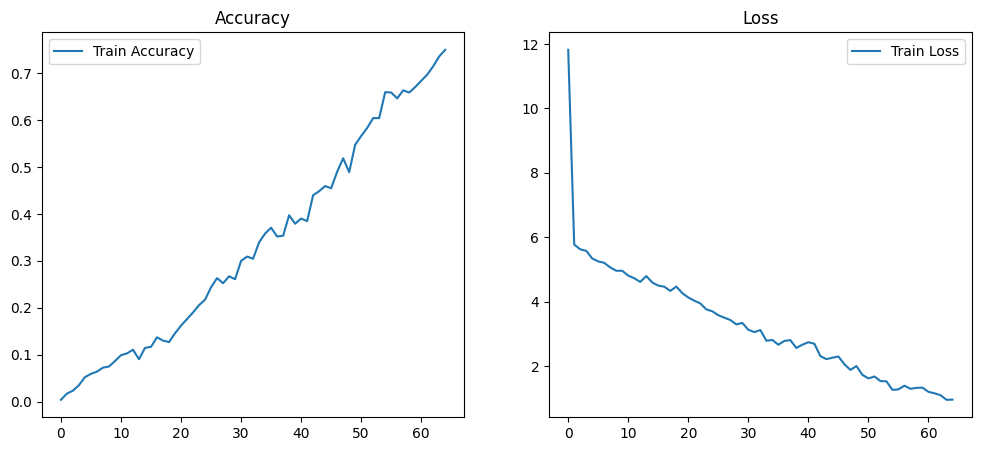

In [89]:
# Plot accuracy & loss
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.legend()
plt.title('Loss')

plt.show()


In [150]:
from tensorflow.keras.models import load_model
import cv2
import numpy as np
import pickle

# Load model
model = load_model('cvl_author_classifier.keras')

# Load label encoder
with open('label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

# Predict author from a new image
def predict_author(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Failed to load image: {image_path}")

    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    img = img.reshape(1, 224, 224, 1)

    pred = model.predict(img)
    label_index = np.argmax(pred)

    author_id = label_encoder.inverse_transform([label_index])[0]
    return author_id





In [151]:
# Example usage
image_path = 'dataset2/cvl-database-cropped-1-1/zain-3-cropped.tiff'
predicted_author = predict_author(image_path)
print(f"Predicted author: {predicted_author}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
Predicted author: 0197
